In [1]:
# Import required packages
import torch
from torch import nn
from torch.distributions import Uniform
import numpy as np
import normflows as nf

from matplotlib import pyplot as plt

from tqdm import tqdm
from asrl.realnvp2d.nf.realnvp2d import init_realnvp2d
from time import perf_counter

Z shape: torch.Size([2, 2, 128])


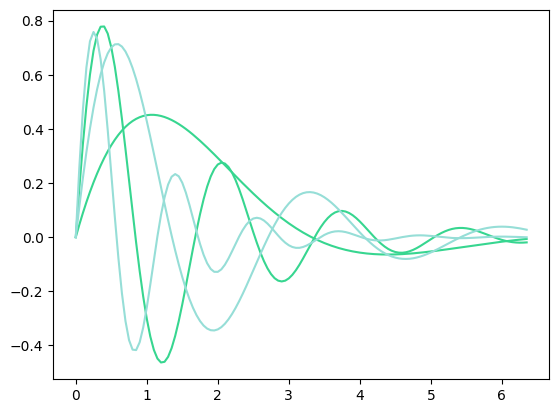

In [2]:
n_channels = 2
horizon = 128

class SinDataset:
    def __init__(self, horizon):
        self.horizon = horizon
    
        self.sin_rate = Uniform(1.0, 6.0)
        self.exp_rate = Uniform(0.5, 2.0)
        
        self.sz = 10_000
        self.samples = self._sample(self.sz)
    
    def sample(self, n_samples):
        inds = torch.randint(0, self.sz, (n_samples,))
        return self.samples[inds, :, :]
    
    def _sample(self, n_samples):
        dt = 0.05
        ts_integer = torch.arange(0, self.horizon, 1).reshape(1, -1)
        ts_integer = torch.tile(ts_integer, (n_samples, 1))
        ts_float = ts_integer.float() * dt
                
        sin_rates = self.sin_rate.sample((n_samples, 1))
        exp_rates = self.exp_rate.sample((n_samples, 1))
        CH1 = torch.sin(sin_rates * ts_float) * torch.exp(-exp_rates * ts_float)
        
        sin_rates = self.sin_rate.sample((n_samples, 1))
        exp_rates = self.exp_rate.sample((n_samples, 1))
        CH2 = torch.sin(sin_rates/2 * ts_float) * torch.exp(-exp_rates/2 * ts_float)
        
        X = torch.stack([CH1, CH2], dim=1)
        return X

target = SinDataset(horizon)

n_samples = 2
Z = target.sample(n_samples)
print(f"Z shape: {Z.shape}")

for i in range(n_samples):
    # pick a random color
    ts = torch.arange(0, horizon, 1).float() * 0.05
    X = Z[i, 0, :]
    Y = Z[i, 1, :]
    color = np.random.rand(3,)
    
    plt.plot(ts.numpy(), X.numpy(), color=color)
    plt.plot(ts.numpy(), Y.numpy(), color=color)
    

In [3]:
model = init_realnvp2d(n_channels=n_channels, seq_len=horizon, n_layers=3)
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

# Print number of params in model
print(f"Number of parameters in the model: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Initializing RealNVP2D with 3 layers and 2 channels for a sequence of length 128
Level 0, Layer 0; mask shape=torch.Size([2, 128]), even=True (checkerboard)
Level 0, Layer 1; mask shape=torch.Size([2, 128]), even=False (checkerboard)
Level 0, Layer 2; mask shape=torch.Size([2, 128]), even=True (checkerboard)
Level 0, Layer 0; mask shape=torch.Size([4, 64]), even=False (mid channel split)
Level 0, Layer 1; mask shape=torch.Size([4, 64]), even=True (mid channel split)
Level 0, Layer 2; mask shape=torch.Size([4, 64]), even=False (mid channel split)
Level 1, Layer 0; mask shape=torch.Size([4, 64]), even=False (checkerboard)
Level 1, Layer 1; mask shape=torch.Size([4, 64]), even=True (checkerboard)
Level 1, Layer 2; mask shape=torch.Size([4, 64]), even=False (checkerboard)
Level 1, Layer 0; mask shape=torch.Size([8, 32]), even=True (mid channel split)
Level 1, Layer 1; mask shape=torch.Size([8, 32]), even=False (mid channel split)
Level 1, Layer 2; mask shape=torch.Size([8, 32]), even=True 

In [ ]:
# Train model
max_iter = 10_000
num_samples = 256
show_iter = 500

loss_hist = np.array([])

stats = {
    'target_sample_time': 0.0,
    'forward_time': 0.0,
    'backward_time': 0.0,
    'optimizer_step_time': 0.0,
}

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    # Get training samples
    start = perf_counter()
    x = target.sample(num_samples).to(device)
    stats['target_sample_time'] += perf_counter() - start
        
    # Compute loss
    start = perf_counter()
    loss = model.forward_kld(x)
    stats['forward_time'] += perf_counter() - start
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        start = perf_counter()
        loss.backward()
        stats['backward_time'] += perf_counter() - start
        
        start = perf_counter()
        optimizer.step()
        stats['optimizer_step_time'] += perf_counter() - start
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if it % show_iter == 0:
        print(f'Iter {it + 1}/{max_iter}, Loss: {loss_hist[-1]}')
        print(f'Stats:')
        print(f'  Target sample time: {stats["target_sample_time"]/show_iter:.6f}s')
        print(f'  Forward time: {stats["forward_time"]/show_iter:.6f}s')
        print(f'  Backward time: {stats["backward_time"]/show_iter:.6f}s')
        print(f'  Optimizer step time: {stats["optimizer_step_time"]/show_iter:.6f}s')
        
        # Reset stats
        stats['target_sample_time'] = 0.0
        stats['forward_time'] = 0.0
        stats['backward_time'] = 0.0
        stats['optimizer_step_time'] = 0.0

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


  0%|          | 2/10000 [00:00<42:43,  3.90it/s]  

Iter 1/10000, Loss: 241.28271484375
Stats:
  Target sample time: 0.000002s
  Forward time: 0.000514s
  Backward time: 0.000226s
  Optimizer step time: 0.000083s


  5%|▌         | 502/10000 [01:07<21:06,  7.50it/s]

Iter 501/10000, Loss: -1286.65185546875
Stats:
  Target sample time: 0.000657s
  Forward time: 0.037354s
  Backward time: 0.022319s
  Optimizer step time: 0.002768s


  6%|▌         | 623/10000 [01:23<20:50,  7.50it/s]

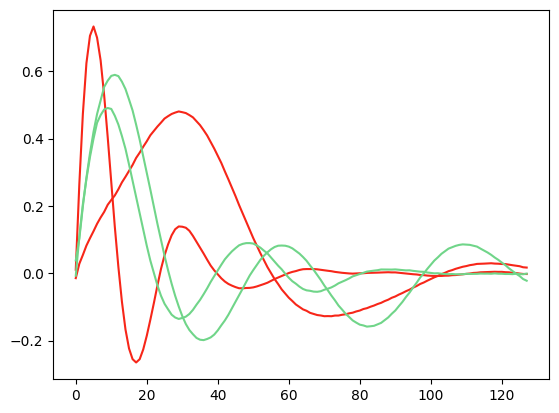

In [ ]:
model_samples = model.sample(num_samples=2)
samples, _ = model_samples

for i in range(samples.shape[0]):
    color = np.random.rand(3,)
    
    for j in range(n_channels):
        ch1 = samples[i, j, :].cpu().detach().numpy()
        plt.plot(ch1, color=color)

plt.show()